### Mar 11 quadratic zeeman

In [146]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [182]:
freq = 8.93
date = "Mar 20"
vHoriz = 1106 # mV
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_10s_" + str(vHoriz) + ".csv")
vHoriz = vHoriz / 1000

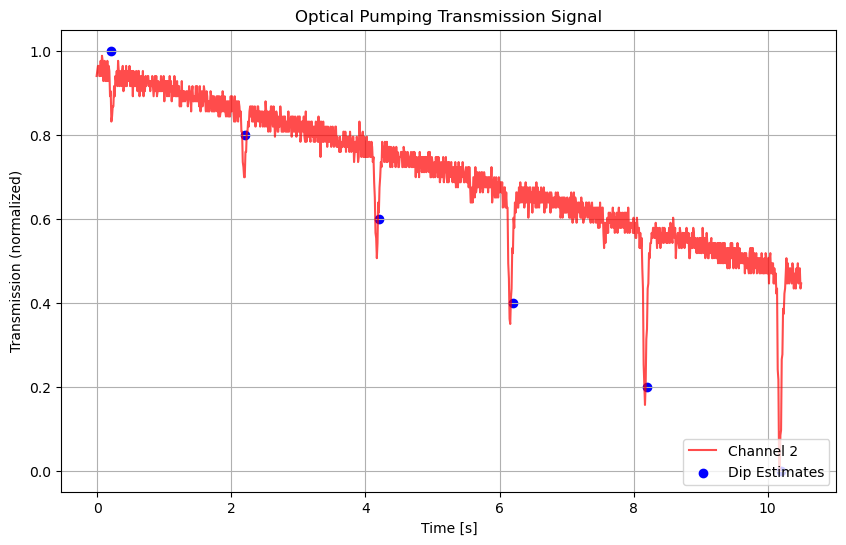

In [188]:
t0 = 1
tf = 11.5
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([0.2,2.2,4.2,6.2,8.2,10.2])

m.plot_quadraticZeeman_sextuple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [189]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4",  "h5", "g5", "x0_5",  "h6", "g6", "x0_6"]
p0 = (1, -0.02, 0.2, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3], 0.5, 0.1, x0s[4], 0.5, 0.1, x0s[5])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.sextuple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.9584505030577994
m -0.04664799549019376
h1 0.114752366829956
g1 0.020761845397028356
x0_1 0.21977102528261908
h2 0.16888880771187248
g2 0.023923385036114568
x0_2 2.192050507926692
h3 0.259999277877054
g3 0.024494761088152815
x0_3 4.169245673350495
h4 0.3297107112094689
g4 0.02663093179309648
x0_4 6.160515018537478
h5 0.4350561619590575
g5 0.025267910140174873
x0_5 8.171053613142568
h6 0.5012043183832207
g6 0.024821431572822607
x0_6 10.182133486692395


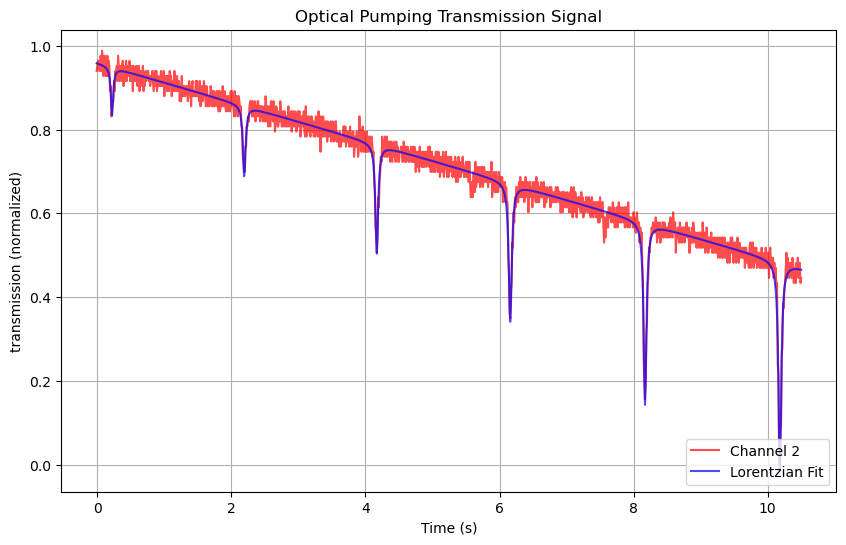

In [190]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)


In [191]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0
x0_5_u = ufloat(popt[16], perr[16]) + t0
x0_6_u = ufloat(popt[19], perr[19]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)
x0_5_index = int(x0_5_u.n // dt)
x0_6_index = int(x0_6_u.n // dt)

numAvg = 10


# vMeasured =0.3045  # V
vShift = ufloat(vHoriz,0.0001) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(0.30,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]))
v_5 = ufloat(np.mean(y1[x0_5_index - numAvg : x0_5_index + numAvg]),
             np.std(y1[x0_5_index - numAvg : x0_5_index + numAvg]))
v_6 = ufloat(np.mean(y1[x0_6_index - numAvg : x0_6_index + numAvg]),
             np.std(y1[x0_6_index - numAvg : x0_6_index + numAvg]))

VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100) * 1.03360784475
VtoBHoriz = ufloat(1.705174,0.028108) / 1000

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip5 = (v_5-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip6 = (v_6-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")
print(f"B field of dip 5: {dip5:.3e}")
print(f"B field of dip 6: {dip6:.3e}")

B field of dip 1: (1.869+/-0.031)e-03
B field of dip 2: (1.881+/-0.031)e-03
B field of dip 3: (1.892+/-0.031)e-03
B field of dip 4: (1.904+/-0.031)e-03
B field of dip 5: (1.915+/-0.031)e-03
B field of dip 6: (1.927+/-0.031)e-03


In [192]:
filepath = 'models/quadraticRb85ZeemanData.csv'

m.append_to_sextupleZeeman_csv(freq, (dip1,dip2,dip3,dip4,dip5,dip6), filepath)

In [222]:
freq = 13.4
date = "Mar 20"
vHoriz = 1100 # mV
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_10s_" + str(vHoriz) + ".csv")
vHoriz = vHoriz / 1000

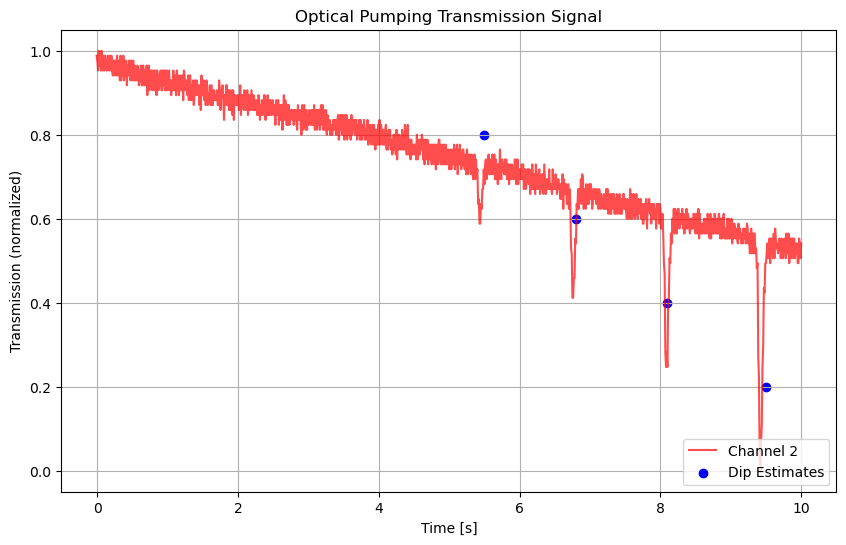

In [227]:
t0 = 1
tf = 11
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([5.5,6.8,8.1,9.5])

m.plot_quadraticZeeman_quadruple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [228]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4"]
p0 = (1, -0.02, 1, 0.1, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,10,2,2,10,2,2,10,2,2,10)

# print(len(p0))
# print(len(variables))
# print(len(lower_bound))
# print(len(upper_bound))

bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.quadruple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.9706006071333744
m -0.0441442642199298
h1 0.14510386478528603
g1 0.024654432029987686
x0_1 5.4380811416817885
h2 0.2734605426314097
g2 0.025417160952620744
x0_2 6.761126208167012
h3 0.39150045574548215
g3 0.02590369696703746
x0_3 8.088735466254915
h4 0.5791412034303385
g4 0.026231800392568037
x0_4 9.423332192354136


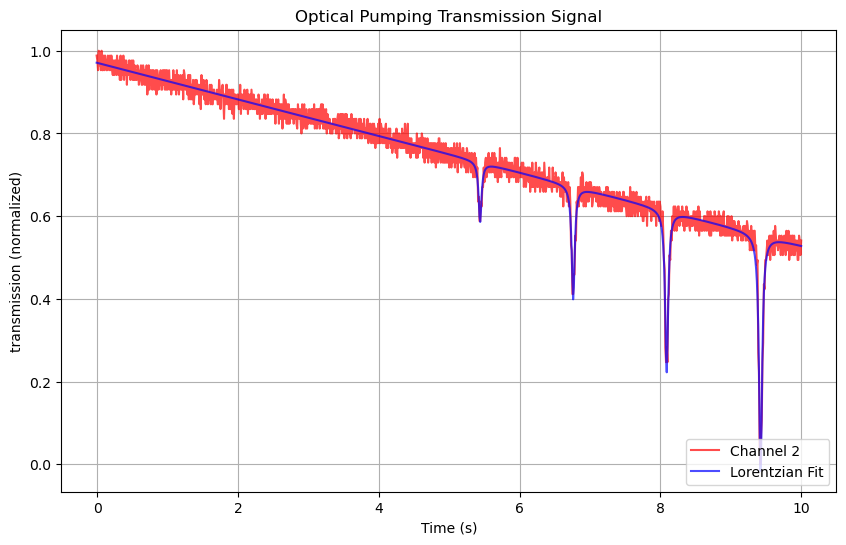

In [229]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.quadruple_lorentz, "fit to " + savename)


In [230]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)

numAvg = 10

vShift = ufloat(vHoriz,0.00001) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]))

VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100) * 1.03360784475
VtoBHoriz = ufloat(1.705174,0.028108) / 1000

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")

B field of dip 1: (1.889+/-0.031)e-03
B field of dip 2: (1.897+/-0.031)e-03
B field of dip 3: (1.904+/-0.031)e-03
B field of dip 4: (1.912+/-0.031)e-03


In [231]:
filepath = 'models/quadraticRb87ZeemanData.csv'

m.append_to_quadrupleZeeman_csv(freq, (dip1,dip2,dip3,dip4), filepath)